In [1]:
import numpy as np
import matplotlib.pyplot as plt
from map_utils import RectRegion, CircleRegion, RegionManager, RegionTag

def make_base_map(H, W, base_cost=1.0, noise=0.0, seed=0):
    """
    create traversability map:
    - base_cost: 全图基础代价
    - noise: 噪声幅度（0 表示无噪声）
    """
    rng = np.random.default_rng(seed)
    T = np.full((H, W), float(base_cost), dtype=float)
    if noise > 0:
        T = T + rng.normal(loc=0.0, scale=noise, size=(H, W))
        T = np.clip(T, 0.01, None)  
    return T

def plot_map(T, title="Traversability Map", show_inf_as_max=True):

    T_vis = T.copy()
    if show_inf_as_max:
        finite_vals = T_vis[np.isfinite(T_vis)]
        maxv = finite_vals.max() if finite_vals.size > 0 else 1.0
        T_vis[~np.isfinite(T_vis)] = maxv * 1.2

    plt.figure(figsize=(16, 16))
    im = plt.imshow(T_vis, origin="lower")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()



region added


In [2]:
rm = RegionManager()

# indoor rectangle
building1 = RectRegion(
    name="building1",
    tag=RegionTag.INDOOR,
    score=5.0,
    x0=0, y0=75,
    x1=75, y1=125
)
building2 = RectRegion(
    name="building2",
    tag=RegionTag.INDOOR,
    score=7.0,
    x0=50, y0=0,
    x1=75, y1=75
)

# outdoor area
yard = RectRegion(
    name="yard",
    tag=RegionTag.OUTDOOR,
    score=2.5,
    x0=125, y0=0,
    x1=200, y1=75
)

# no-traversable obstacle
turtlepound = RectRegion(
    name="turtlepound",
    tag=RegionTag.NO_TRAVERSABLE,
    score=float("inf"),
    x0=125, y0=75,
    x1=150, y1=200
)

# turtlepound = CircleRegion(
#     name="turtlepound",
#     tag=RegionTag.NO_TRAVERSABLE,
#     score=float("inf"),
#     cx=60, cy=60,
#     r=5
# )

rm.add_region(building1)
rm.add_region(building2)
rm.add_region(yard)
rm.add_region(turtlepound)



In [3]:
dm = RegionManager()

# building1
door1 = RectRegion(
    name="door1",
    tag=RegionTag.DOOR,
    score=10.0,
    x0=25, y0=122,
    x1=50, y1=127
)
door2 = RectRegion(
    name="door2",
    tag=RegionTag.DOOR,
    score=10.0,
    x0=10, y0=73,
    x1=30, y1=78
)
# building2
door3 = RectRegion(
    name="door3",
    tag=RegionTag.DOOR,
    score=10.0,
    x0=48, y0=15,
    x1=52, y1=35,
)
door4 = RectRegion(
    name="door4",
    tag=RegionTag.DOOR,
    score=10.0,
    x0=73, y0=15,
    x1=77, y1=35,
)
dm.add_region(door1)
dm.add_region(door2)
dm.add_region(door3)
dm.add_region(door4)

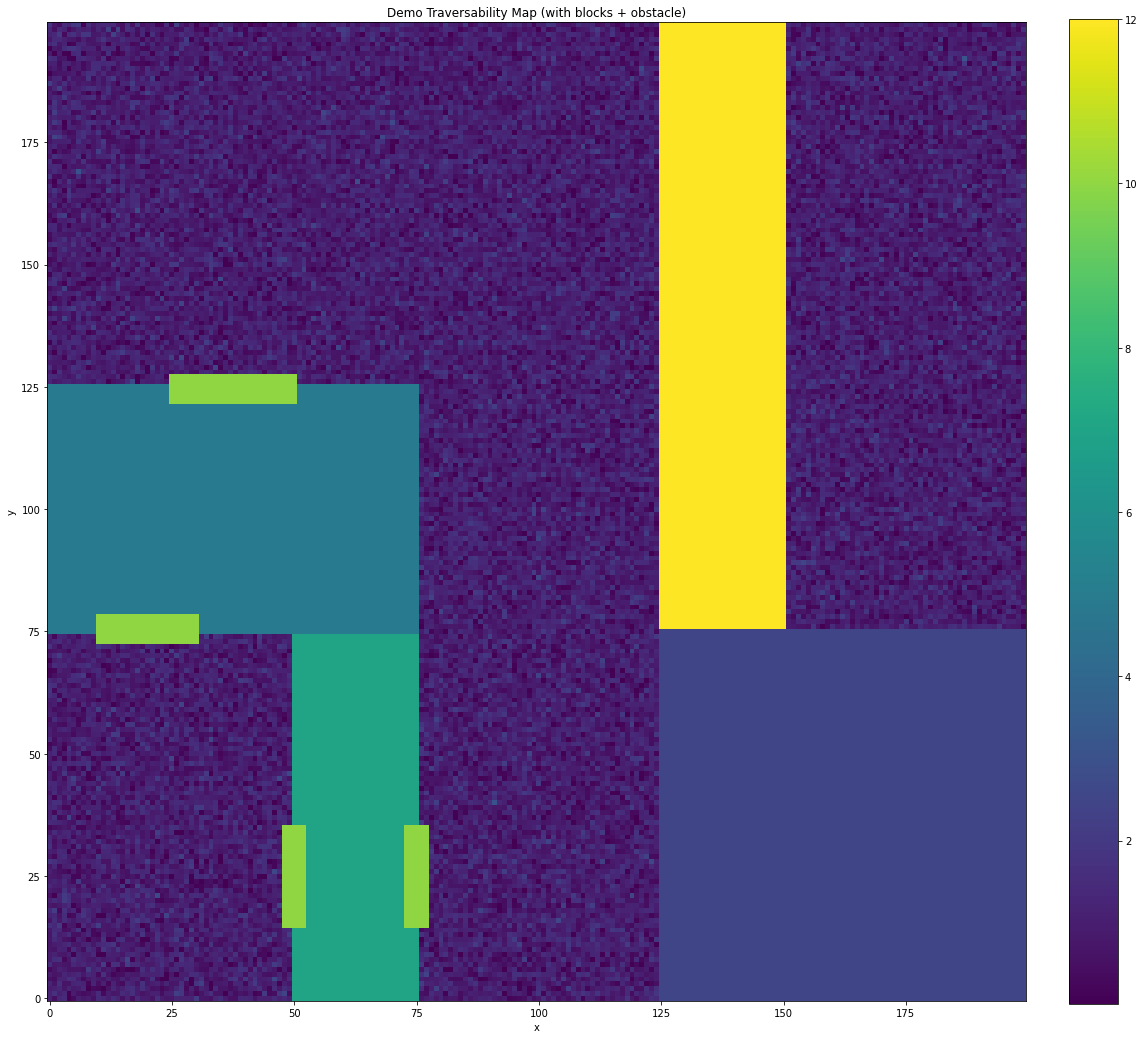

In [4]:
# ============ create map============
H, W = 200, 200
T = make_base_map(H, W, base_cost=1.0, noise=0.5, seed=42)

# plot_map(T, title="Demo Traversability Map (with blocks + obstacle)")

# ============ add region============
for y in range(H):
    for x in range(W):     
        if rm.query_tag(x, y) !="unknown":
            T[y, x] = rm.query_score(x, y)
        if dm.query_tag(x, y) !="unknown":
            T[y, x] = dm.query_score(x, y)            
            
plot_map(T, title="Demo Traversability Map (with blocks + obstacle)")


In [5]:
def plot_region_masks(rm, region_name: str, res: float):
    """
    Visualize occupancy and boundary mask for a given region.
    """
    if region_name not in rm.occupancy_masks:
        raise ValueError(f"No occupancy mask for region {region_name}")
    if region_name not in rm.boundary_masks:
        raise ValueError(f"No boundary mask for region {region_name}")

    occ = rm.occupancy_masks[region_name]
    bnd = rm.boundary_masks[region_name]

    H, W = occ.shape
    extent = [0, W*res, 0, H*res]

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Occupancy mask
    axs[0].imshow(occ, origin="lower", extent=extent)
    axs[0].set_title(f"Occupancy mask: {region_name}")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")

    # Boundary mask
    axs[1].imshow(bnd, origin="lower", extent=extent)
    axs[1].set_title(f"Boundary mask (4-neighborhood): {region_name}")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("y")

    plt.tight_layout()
    plt.show()
    
def plot_mask_with_geometry(rm, region_name, res):
    occ = rm.occupancy_masks[region_name]
    bnd = rm.boundary_masks[region_name]
    r = rm.get_region_by_name(region_name)

    H, W = occ.shape
    extent = [0, W*res, 0, H*res]

    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(bnd, origin="lower", extent=extent, cmap="Reds")

    # Draw geometry outline
    if isinstance(r, RectRegion):
        xs = [r.x0, r.x1, r.x1, r.x0, r.x0]
        ys = [r.y0, r.y0, r.y1, r.y1, r.y0]
        ax.plot(xs, ys, "b-", lw=2)

    elif isinstance(r, CircleRegion):
        theta = np.linspace(0, 2*np.pi, 200)
        xs = r.cx + r.r * np.cos(theta)
        ys = r.cy + r.r * np.sin(theta)
        ax.plot(xs, ys, "b-", lw=2)

    ax.set_title(f"Boundary mask + geometry: {region_name}")
    ax.set_aspect("equal")
    plt.show()

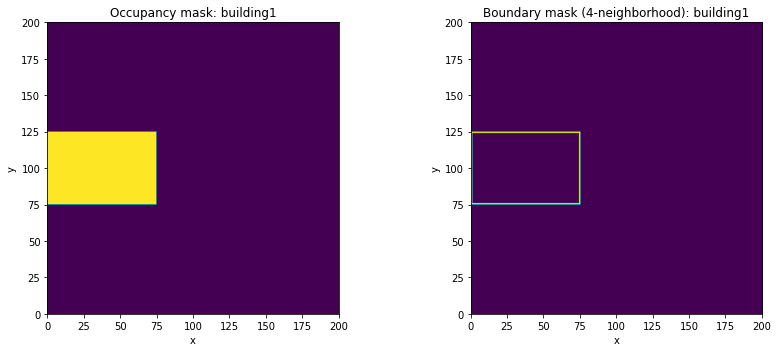

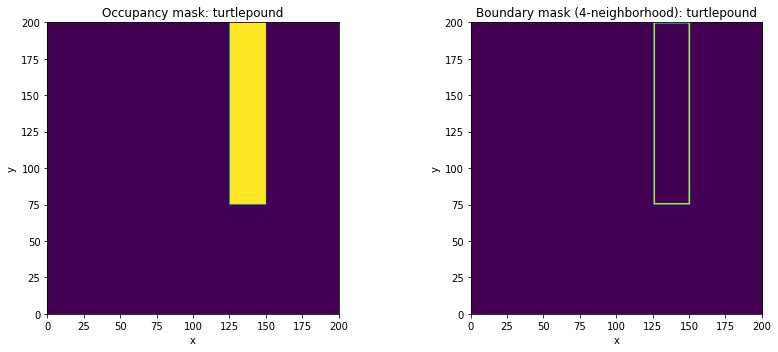

In [6]:
width = 200
height = 200
res = 1 
rm.compute_boundary_masks(width, height, res, connectivity=4)
plot_region_masks(rm, "building1", res)
plot_region_masks(rm, "turtlepound", res)
# plot_mask_with_geometry(rm, "building1", res)
# plot_mask_with_geometry(rm, "building2", res)

In [7]:
from map_utils import RegionManager, RectRegion, CircleRegion, RegionTag
from graph_utils import NodeSampler, TAG_DOOR, GraphBuilderKNN

sampler = NodeSampler(width=200, height=200, region_manager=rm, door_manager=dm, rng_seed=42)

g = sampler.make_graph_with_nodes(
    n_random=430,
    n_door=8,
    min_dist=8.0,
    random_allowed_tags=["indoor", "outdoor","unknown", "no-traversable"]
)
# print(len(g), g.node_ids_by_tag.keys())
domain_tags = ["indoor", "outdoor", "unknown","no-traversable"]


# mask = rm.boundary_masks["turtlepound"]
# print("mask shape(H,W) =", mask.shape)
# print("boundary cells =", int(mask.sum()))
# H, W = mask.shape
# print("implied world size by mask+res:", W*1.0, H*1.0)
# print("sampler.W/H =", sampler.W, sampler.H)

added = sampler.add_portal_nodes_from_region_boundary(
    g,
    "turtlepound",
    n=25,
    res=1.0,
    min_dist=8,
    stride=1,
    door_tag="door",
    jitter=0.0,
)
added = sampler.add_portal_nodes_from_region_boundary(
    g,
    "yard",
    n=20,
    res=1.0,
    min_dist=8,
    stride=1,
    door_tag="door",
    jitter=0.0,
)



# builder = GraphBuilderKNN(domain_tags=domain_tags, portal_tag="door")
# builder.build_edges(
#     g,
#     k_intra=10,
#     k_portal=4,
#     r_max=14.0,
#     portal_targets=["indoor", "unknown"],   # door 只桥接 indoor/outdoor
# )

builder = GraphBuilderKNN(domain_tags=["indoor","outdoor","unknown","no-traversable"], portal_tag="door")
builder.build_edges(g, k_intra=5, k_portal=5, r_max=15,r_max_portal=15)


print("nodes:", len(g.nodes), "edges:", len(g.edges))

print("portal edges:", len(g.edge_ids("portal")))


nodes: 483 edges: 1283
portal edges: 257


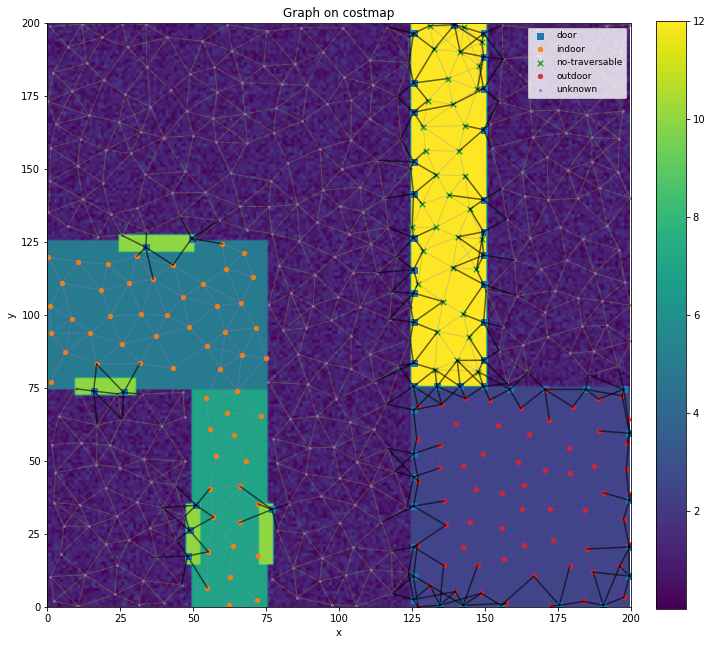

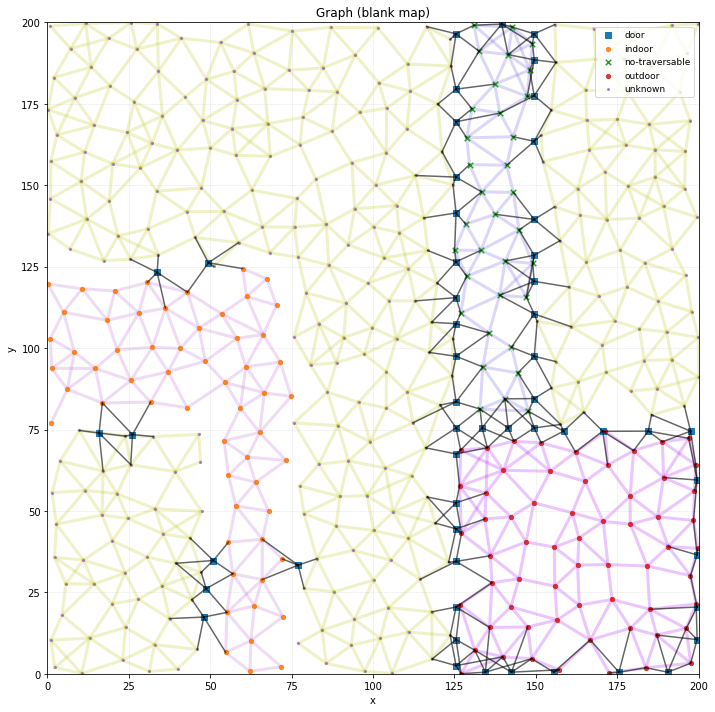

{'indoor': (0.7739560485559633, 0.4388784397520523, 0.8585979199113825),
 'outdoor': (0.6973680290593639, 0.09417734788764953, 0.9756223516367559),
 'unknown': (0.761139701990353, 0.7860643052769538, 0.12811363267554587),
 'no-traversable': (0.45038593789556713,
  0.37079802423258124,
  0.9267649888486018)}

In [44]:
from viz_utils import plot_graph_on_blank, plot_graph_on_costmap,plot_graph_edges

domain_colors = plot_graph_on_costmap(T, g, portal_color="black", edge_color_seed=42,figsize=(10,10))
# plot_graph_on_costmap(T, g, domain_colors=domain_colors, portal_color="black", figsize=(10,10))
plot_graph_on_blank(g, width=200, domain_colors=domain_colors,height=200, edge_linewidth=3,figsize=(10,10))

